In [1]:
# =========================
# CELL 1: LOAD DATA + GROUPS
# =========================

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import pandas as pd
import os

# ---- PATH ----
phy_path = r"C"

# ---- LOAD ----
sorting = se.read_phy(phy_path)

cg_path = os.path.join(phy_path, "cluster_group.tsv")
df = pd.read_csv(cg_path, sep="\t")

unit_ids_all = sorting.get_unit_ids()
sf = sorting.get_sampling_frequency()

# ---- GROUPS ----
good_cluster_ids = set(df[df["group"] == "good"]["cluster_id"].values)
noise_cluster_ids = set(df[df["group"] == "noise"]["cluster_id"].values)

good_units = [u for u in unit_ids_all if u in good_cluster_ids]
noise_units = [u for u in unit_ids_all if u in noise_cluster_ids]

sorting_good = sorting.select_units(good_units)
sorting_noise = sorting.select_units(noise_units)

print(f"✅ Good units: {len(good_units)}")
print(f"⚠️ Noise units: {len(noise_units)}")

# =========================
# LOAD NI TTL + SELECT PIN
# =========================

import numpy as np
import os

# ---- SET PATH ----
ni_folder = r""

# ---- SELECT TTL PIN ----
TTL_PIN = 6   # 👈 CHANGE THIS (0–15 typically)

print("Using NI folder:")
print(ni_folder)
print(f"Using TTL pin: {TTL_PIN}")

# ---- LOAD FILES ----
timestamps_path = os.path.join(ni_folder, "timestamps.npy")
states_path     = os.path.join(ni_folder, "states.npy")
full_words_path = os.path.join(ni_folder, "full_words.npy")

if not os.path.exists(full_words_path):
    print("❌ TTL files not found")

else:
    timestamps_ni = np.load(timestamps_path)
    states_ni     = np.load(states_path)
    full_words_ni = np.load(full_words_path)

    print("✅ TTL data loaded")
    print("Samples:", len(full_words_ni))
    print("Duration (s):", timestamps_ni[-1] - timestamps_ni[0])

    # =========================
    # EXTRACT SPECIFIC TTL CHANNEL
    # =========================
    bit_mask = 1 << TTL_PIN

    ttl_signal = (full_words_ni & bit_mask) > 0  # boolean signal

    # ---- FIND RISING EDGES ----
    ttl_diff = np.diff(ttl_signal.astype(int))

    rising_edges = np.where(ttl_diff == 1)[0] + 1

    ttl_times_all = timestamps_ni[rising_edges]  # ✅ keep original

    ttl_times = ttl_times_all.copy()  # working variable

    print(f"⏱️ Extracted {len(ttl_times_all)} TTL events from pin {TTL_PIN}")

    print(f"⏱️ Extracted {len(ttl_times)} TTL events from pin {TTL_PIN}")

# =========================
# TTL REFRACTORY FILTER
# =========================

min_interval = 5.0  # seconds (your choice)

filtered_ttl_times = []
last_kept_time = -np.inf

for t in ttl_times:
    if t - last_kept_time >= min_interval:
        filtered_ttl_times.append(t)
        last_kept_time = t

filtered_ttl_times = np.array(filtered_ttl_times)

print(f"\n🧹 TTL filtering applied (min interval = {min_interval}s)")
print(f"Original TTLs: {len(ttl_times)}")
print(f"Filtered TTLs: {len(filtered_ttl_times)}")

# overwrite for downstream analysis
ttl_times = filtered_ttl_times

C:\ProgramData\anaconda3\envs\spikeinterface_env_vid\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory: 'C\\spike_times.npy'

In [6]:
# =========================
# CELL 2: MODULATION SCREEN (GLOBAL BASELINE VERSION)
# =========================

# ---- PARAMETERS ----
pre_time = 10.0    # 👈 expanded window
post_time = 10.0

event_window = (0.0, 2.0)

bin_size = 0.050

MI_THRESHOLD = 0.35
MIN_SPIKES = 50

# ---- GLOBAL BASELINE WINDOW (ABSOLUTE TIME) ----
global_baseline = (50.0, 200.0)


def compute_global_baseline(spike_times, baseline_window):
    mask = (spike_times >= baseline_window[0]) & (spike_times <= baseline_window[1])
    duration = baseline_window[1] - baseline_window[0]

    rate = np.sum(mask) / duration

    if rate == 0:
        rate = 1e-6

    return rate


def screen_units(sorting_obj, unit_list, label="group"):

    selected = []
    MI_values = {}
    baseline_rates = {}

    for unit in unit_list:

        spike_train = sorting_obj.get_unit_spike_train(unit)
        spike_times = spike_train / sf

        if len(spike_times) < MIN_SPIKES:
            continue

        # =========================
        # GLOBAL BASELINE
        # =========================
        baseline_rate = compute_global_baseline(spike_times, global_baseline)
        baseline_rates[unit] = baseline_rate

        # =========================
        # ALIGN SPIKES TO TTL
        # =========================
        aligned_spikes = []

        for t in ttl_times:
            rel = spike_times - t
            mask = (rel >= -pre_time) & (rel <= post_time)
            aligned_spikes.append(rel[mask])

        if len(aligned_spikes) == 0:
            continue

        aligned_spikes = np.concatenate(aligned_spikes)

        # =========================
        # EVENT RATE
        # =========================
        event_mask = (aligned_spikes >= event_window[0]) & (aligned_spikes < event_window[1])

        event_rate = np.sum(event_mask) / (len(ttl_times) * (event_window[1] - event_window[0]))

        # =========================
        # MODULATION INDEX (GLOBAL BASELINE)
        # =========================
        if (baseline_rate + event_rate) == 0:
            MI = 0
        else:
            MI = (event_rate - baseline_rate) / (baseline_rate + event_rate)

        MI_values[unit] = MI

        if abs(MI) >= MI_THRESHOLD:
            selected.append(unit)

        # ---- PRINT BASELINE ----
        print(f"Unit {unit}: baseline = {baseline_rate:.2f} Hz | event = {event_rate:.2f} Hz | MI = {MI:.3f}")

    print(f"\n📊 {label}")
    print(f"Units passing threshold: {len(selected)} / {len(unit_list)}")

    return selected, MI_values, baseline_rates


# =========================
# RUN
# =========================

selected_units, modulation_info, baseline_rates_good = screen_units(
    sorting_good, good_units, label="GOOD UNITS"
)

noise_selected_units, noise_MI, baseline_rates_noise = screen_units(
    sorting_noise, noise_units, label="NOISE UNITS"
)

Unit 0: baseline = 10.42 Hz | event = 17.00 Hz | MI = 0.240
Unit 1: baseline = 9.41 Hz | event = 12.24 Hz | MI = 0.131
Unit 2: baseline = 13.08 Hz | event = 19.12 Hz | MI = 0.188
Unit 10: baseline = 6.88 Hz | event = 14.93 Hz | MI = 0.369
Unit 11: baseline = 11.56 Hz | event = 14.30 Hz | MI = 0.106
Unit 12: baseline = 10.37 Hz | event = 12.67 Hz | MI = 0.100
Unit 14: baseline = 19.65 Hz | event = 19.51 Hz | MI = -0.003
Unit 19: baseline = 1.05 Hz | event = 3.28 Hz | MI = 0.516
Unit 23: baseline = 9.41 Hz | event = 17.58 Hz | MI = 0.303
Unit 24: baseline = 3.83 Hz | event = 12.52 Hz | MI = 0.531
Unit 30: baseline = 19.04 Hz | event = 24.53 Hz | MI = 0.126
Unit 31: baseline = 7.75 Hz | event = 10.53 Hz | MI = 0.152
Unit 34: baseline = 18.22 Hz | event = 20.62 Hz | MI = 0.062
Unit 35: baseline = 28.55 Hz | event = 30.68 Hz | MI = 0.036
Unit 38: baseline = 3.14 Hz | event = 12.22 Hz | MI = 0.591
Unit 43: baseline = 11.97 Hz | event = 14.01 Hz | MI = 0.079
Unit 45: baseline = 21.81 Hz | eve

Unit 10 baseline Hz: 6.88
Unit 19 baseline Hz: 1.05
Unit 24 baseline Hz: 3.83
Unit 38 baseline Hz: 3.14
Unit 62 baseline Hz: 5.05
Unit 72 baseline Hz: 2.63
Unit 89 baseline Hz: 1.44
Unit 98 baseline Hz: 5.67
Unit 115 baseline Hz: 8.79
Unit 118 baseline Hz: 6.60
Unit 137 baseline Hz: 4.91
Unit 154 baseline Hz: 1.59
Unit 172 baseline Hz: 5.89
Unit 179 baseline Hz: 4.07
Unit 202 baseline Hz: 4.23
Unit 203 baseline Hz: 10.46
Unit 204 baseline Hz: 1.13
Unit 219 baseline Hz: 4.70
Unit 224 baseline Hz: 2.51
Unit 225 baseline Hz: 2.67
Unit 249 baseline Hz: 1.23
Unit 293 baseline Hz: 9.30
Unit 349 baseline Hz: 0.70
Unit 354 baseline Hz: 0.27
Unit 401 baseline Hz: 2.43


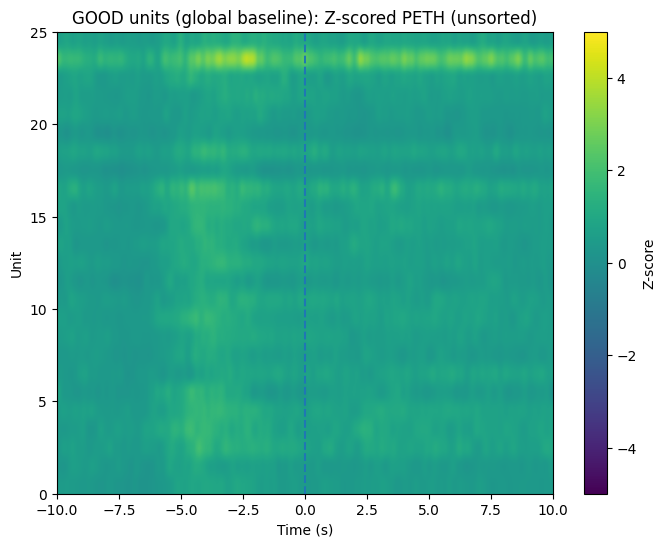

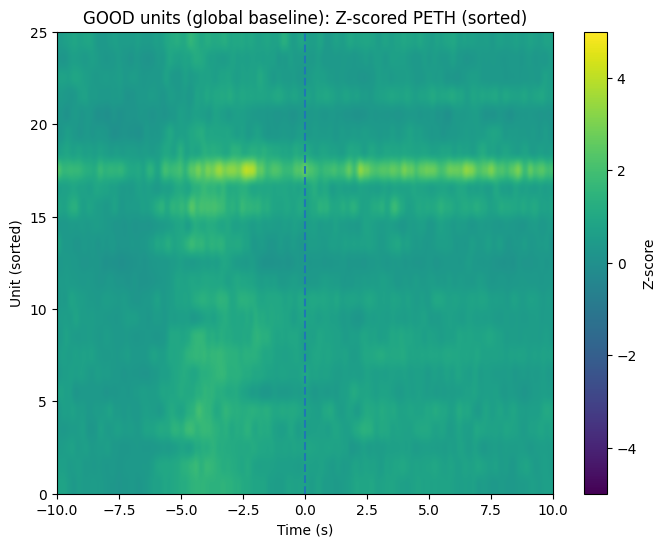

Kept TTLs: 49
Filtered out TTLs: 74


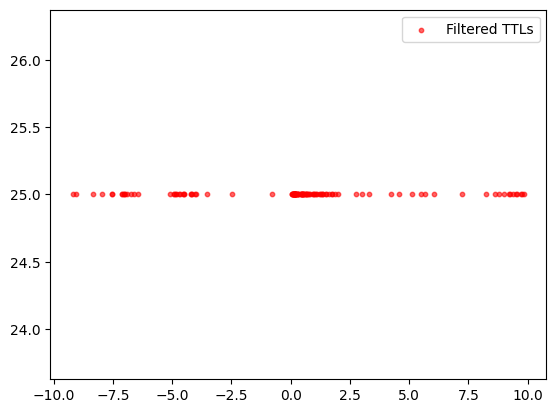

In [13]:
# =========================
# CELL: GOOD UNITS (GLOBAL BASELINE Z-SCORE)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

BASELINE_START = 50.0
BASELINE_END   = 200.0

units = selected_units

all_z = []
unit_MI = []

bins = np.arange(-pre_time, post_time + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

for unit in units:

    spike_train = sorting_good.get_unit_spike_train(unit)
    spike_times = spike_train / sf

    # =========================
    # GLOBAL BASELINE (50–200s)
    # =========================
    baseline_spikes = spike_times[
        (spike_times >= BASELINE_START) &
        (spike_times <= BASELINE_END)
    ]

    baseline_rate = len(baseline_spikes) / (BASELINE_END - BASELINE_START)

    # estimate variance using binning
    baseline_bins = np.arange(BASELINE_START, BASELINE_END, bin_size)
    baseline_counts, _ = np.histogram(baseline_spikes, bins=baseline_bins)
    baseline_rates = baseline_counts / bin_size

    baseline_std = np.std(baseline_rates)
    if baseline_std == 0:
        baseline_std = 1e-6

    print(f"Unit {unit} baseline Hz: {baseline_rate:.2f}")

    # =========================
    # TRIAL MATRIX
    # =========================
    trial_rates = []

    for t in ttl_times:
        rel = spike_times - t
        mask = (rel >= -pre_time) & (rel <= post_time)

        counts, _ = np.histogram(rel[mask], bins=bins)
        trial_rates.append(counts / bin_size)

    trial_rates = np.array(trial_rates)

    if trial_rates.shape[0] == 0:
        continue

    mean_rate = np.mean(trial_rates, axis=0)
    mean_rate_smooth = gaussian_filter1d(mean_rate, sigma=2)

    # =========================
    # GLOBAL Z-SCORE
    # =========================
    z = (mean_rate_smooth - baseline_rate) / baseline_std
    all_z.append(z)

    # =========================
    # DATA-DRIVEN MI
    # =========================
    deviation = mean_rate_smooth - baseline_rate
    MI = deviation[np.argmax(np.abs(deviation))]
    unit_MI.append(MI)

all_z = np.array(all_z)
unit_MI = np.array(unit_MI)

# =========================
# PLOTTING
# =========================

VMIN = -5
VMAX = 5

# ---- UNSORTED ----
plt.figure(figsize=(8,6))
plt.imshow(all_z, aspect='auto',
           extent=[-pre_time, post_time, 0, len(all_z)],
           origin='lower', vmin=VMIN, vmax=VMAX)
plt.axvline(0, linestyle='--')
plt.title("GOOD units (global baseline): Z-scored PETH (unsorted)")
plt.xlabel("Time (s)")
plt.ylabel("Unit")
plt.colorbar(label="Z-score")
plt.show()

# ---- SORTED ----
sort_idx = np.argsort(unit_MI)[::-1]

plt.figure(figsize=(8,6))
plt.imshow(all_z[sort_idx], aspect='auto',
           extent=[-pre_time, post_time, 0, len(all_z)],
           origin='lower', vmin=VMIN, vmax=VMAX)
plt.axvline(0, linestyle='--')
plt.title("GOOD units (global baseline): Z-scored PETH (sorted)")
plt.xlabel("Time (s)")
plt.ylabel("Unit (sorted)")
plt.colorbar(label="Z-score")
plt.show()

# =========================
# OPTIONAL TTL OVERLAY (AUTO-DETECT)
# =========================

plot_ttl_overlay = True  # toggle if you ever want to disable

if plot_ttl_overlay and 'ttl_times_all' in globals():

    # identify filtered-out TTLs
    filtered_out = []

    for t in ttl_times_all:
        if np.min(np.abs(ttl_times - t)) > 1e-6:
            filtered_out.append(t)

    filtered_out = np.array(filtered_out)

    print(f"Kept TTLs: {len(ttl_times)}")
    print(f"Filtered out TTLs: {len(filtered_out)}")

    # only proceed if there ARE filtered TTLs
    if len(filtered_out) > 0:

        relative_times = []

        for t_keep in ttl_times:
            diffs = filtered_out - t_keep
            mask = (diffs >= -pre_time) & (diffs <= post_time)
            relative_times.extend(diffs[mask])

        relative_times = np.array(relative_times)

        if len(relative_times) > 0:
            y_top = len(all_z)

            plt.scatter(relative_times,
                        np.ones_like(relative_times) * y_top,
                        s=10, color='red', alpha=0.6,
                        label='Filtered TTLs')

            plt.legend()
        else:
            print("No filtered TTLs fall within plotting window.")

    else:
        print("No TTLs were filtered out — overlay skipped.")

else:
    print("ttl_times_all not found — overlay skipped.")

Kept TTLs: 49
Filtered out TTLs: 74


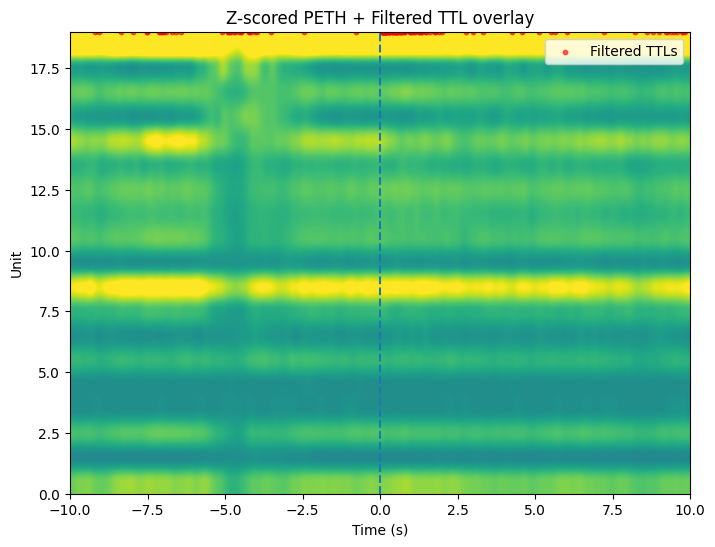

In [12]:
# =========================
# CELL: TTL OVERLAY (KEPT vs FILTERED)
# =========================

# ASSUMES:
# ttl_times = filtered (kept)
# ttl_times_all = original (unfiltered)

filtered_out = []

for t in ttl_times_all:
    if np.min(np.abs(ttl_times - t)) > 1e-6:
        filtered_out.append(t)

filtered_out = np.array(filtered_out)

print(f"Kept TTLs: {len(ttl_times)}")
print(f"Filtered out TTLs: {len(filtered_out)}")

# =========================
# COMPUTE RELATIVE POSITIONS
# =========================

relative_times = []

for t_keep in ttl_times:
    diffs = filtered_out - t_keep
    mask = (diffs >= -pre_time) & (diffs <= post_time)
    relative_times.extend(diffs[mask])

relative_times = np.array(relative_times)

# =========================
# PLOT OVERLAY
# =========================

plt.figure(figsize=(8,6))

# plot existing heatmap again (last computed all_z)
plt.imshow(all_z, aspect='auto',
           extent=[-pre_time, post_time, 0, len(all_z)],
           origin='lower', vmin=VMIN, vmax=VMAX)

plt.axvline(0, linestyle='--')

# ---- OVERLAY FILTERED TTLs ----
y_top = len(all_z)

plt.scatter(relative_times,
            np.ones_like(relative_times) * y_top,
            s=10, color='red', alpha=0.6, label='Filtered TTLs')

plt.title("Z-scored PETH + Filtered TTL overlay")
plt.xlabel("Time (s)")
plt.ylabel("Unit")
plt.legend()

plt.show()

Kept TTLs: 49
Filtered out TTLs: 74


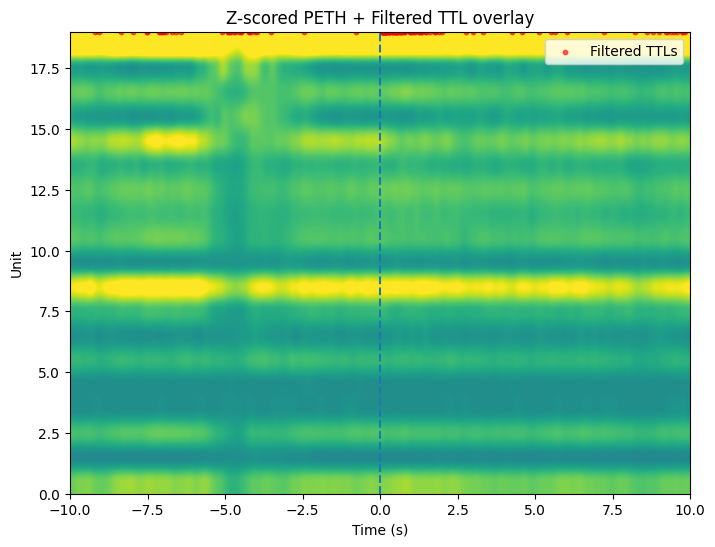

In [11]:
# =========================
# CELL: TTL OVERLAY (KEPT vs FILTERED)
# =========================

# ASSUMES:
# ttl_times = filtered (kept)
# ttl_times_all = original (unfiltered)

filtered_out = []

for t in ttl_times_all:
    if np.min(np.abs(ttl_times - t)) > 1e-6:
        filtered_out.append(t)

filtered_out = np.array(filtered_out)

print(f"Kept TTLs: {len(ttl_times)}")
print(f"Filtered out TTLs: {len(filtered_out)}")

# =========================
# COMPUTE RELATIVE POSITIONS
# =========================

relative_times = []

for t_keep in ttl_times:
    diffs = filtered_out - t_keep
    mask = (diffs >= -pre_time) & (diffs <= post_time)
    relative_times.extend(diffs[mask])

relative_times = np.array(relative_times)

# =========================
# PLOT OVERLAY
# =========================

plt.figure(figsize=(8,6))

# plot existing heatmap again (last computed all_z)
plt.imshow(all_z, aspect='auto',
           extent=[-pre_time, post_time, 0, len(all_z)],
           origin='lower', vmin=VMIN, vmax=VMAX)

plt.axvline(0, linestyle='--')

# ---- OVERLAY FILTERED TTLs ----
y_top = len(all_z)

plt.scatter(relative_times,
            np.ones_like(relative_times) * y_top,
            s=10, color='red', alpha=0.6, label='Filtered TTLs')

plt.title("Z-scored PETH + Filtered TTL overlay")
plt.xlabel("Time (s)")
plt.ylabel("Unit")
plt.legend()

plt.show()

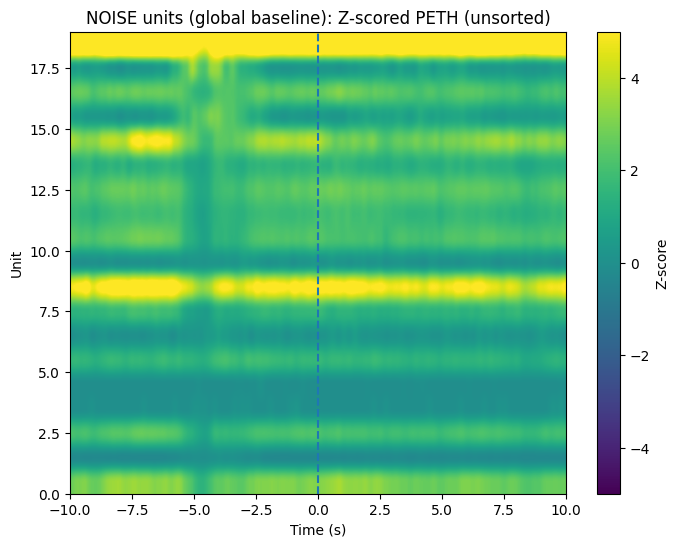

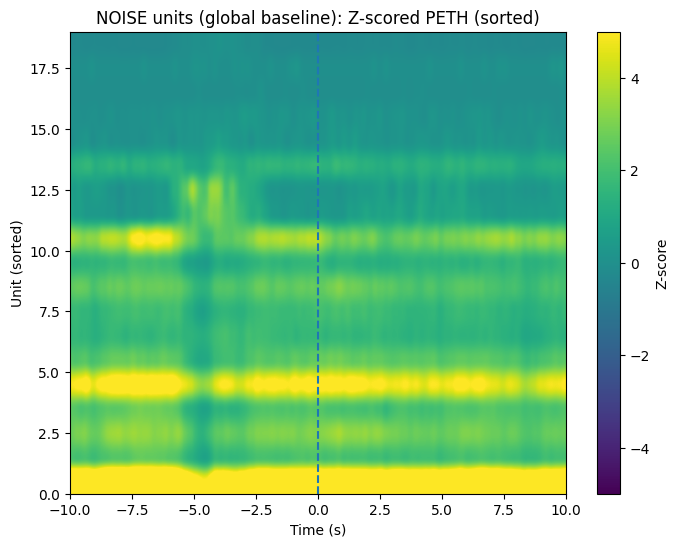

In [8]:
# =========================
# CELL: NOISE UNITS (GLOBAL BASELINE Z-SCORE)
# =========================

units = noise_selected_units

all_z = []
unit_MI = []

for unit in units:

    spike_train = sorting_noise.get_unit_spike_train(unit)
    spike_times = spike_train / sf

    # ---- GLOBAL BASELINE ----
    baseline_spikes = spike_times[
        (spike_times >= BASELINE_START) &
        (spike_times <= BASELINE_END)
    ]

    baseline_rate = len(baseline_spikes) / (BASELINE_END - BASELINE_START)

    baseline_bins = np.arange(BASELINE_START, BASELINE_END, bin_size)
    baseline_counts, _ = np.histogram(baseline_spikes, bins=baseline_bins)
    baseline_rates = baseline_counts / bin_size

    baseline_std = np.std(baseline_rates)
    if baseline_std == 0:
        baseline_std = 1e-6

    trial_rates = []

    for t in ttl_times:
        rel = spike_times - t
        mask = (rel >= -pre_time) & (rel <= post_time)

        counts, _ = np.histogram(rel[mask], bins=bins)
        trial_rates.append(counts / bin_size)

    trial_rates = np.array(trial_rates)

    if trial_rates.shape[0] == 0:
        continue

    mean_rate = np.mean(trial_rates, axis=0)
    mean_rate_smooth = gaussian_filter1d(mean_rate, sigma=2)

    z = (mean_rate_smooth - baseline_rate) / baseline_std
    all_z.append(z)

    deviation = mean_rate_smooth - baseline_rate
    MI = deviation[np.argmax(np.abs(deviation))]
    unit_MI.append(MI)

all_z = np.array(all_z)
unit_MI = np.array(unit_MI)

# ---- PLOTTING ----
VMIN = -5
VMAX = 5

plt.figure(figsize=(8,6))
plt.imshow(all_z, aspect='auto',
           extent=[-pre_time, post_time, 0, len(all_z)],
           origin='lower', vmin=VMIN, vmax=VMAX)
plt.axvline(0, linestyle='--')
plt.title("NOISE units (global baseline): Z-scored PETH (unsorted)")
plt.xlabel("Time (s)")
plt.ylabel("Unit")
plt.colorbar(label="Z-score")
plt.show()

sort_idx = np.argsort(unit_MI)[::-1]

plt.figure(figsize=(8,6))
plt.imshow(all_z[sort_idx], aspect='auto',
           extent=[-pre_time, post_time, 0, len(all_z)],
           origin='lower', vmin=VMIN, vmax=VMAX)
plt.axvline(0, linestyle='--')
plt.title("NOISE units (global baseline): Z-scored PETH (sorted)")
plt.xlabel("Time (s)")
plt.ylabel("Unit (sorted)")
plt.colorbar(label="Z-score")
plt.show()


📊 Plotting 25 units...



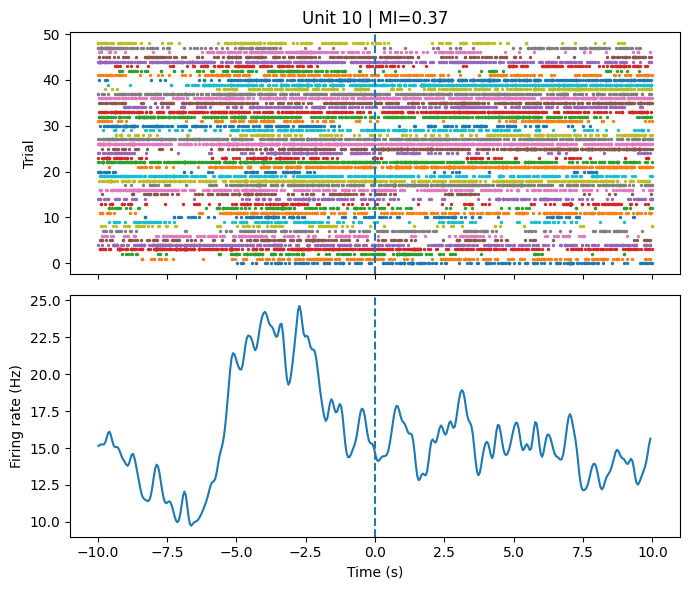

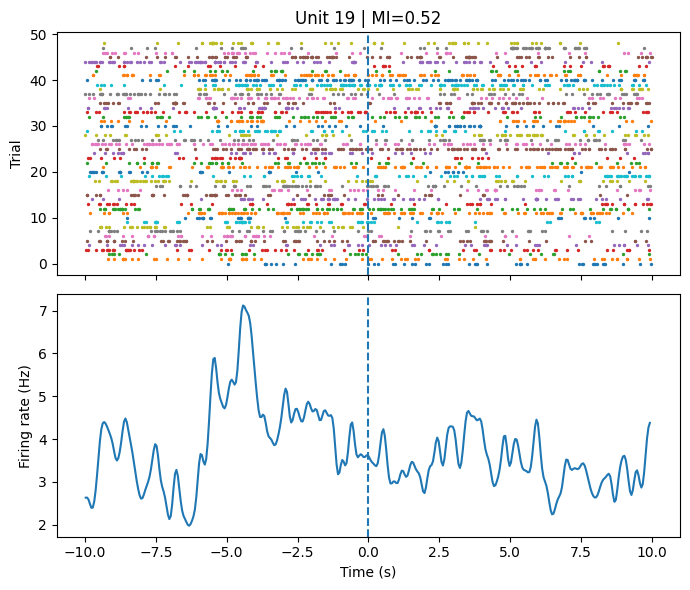

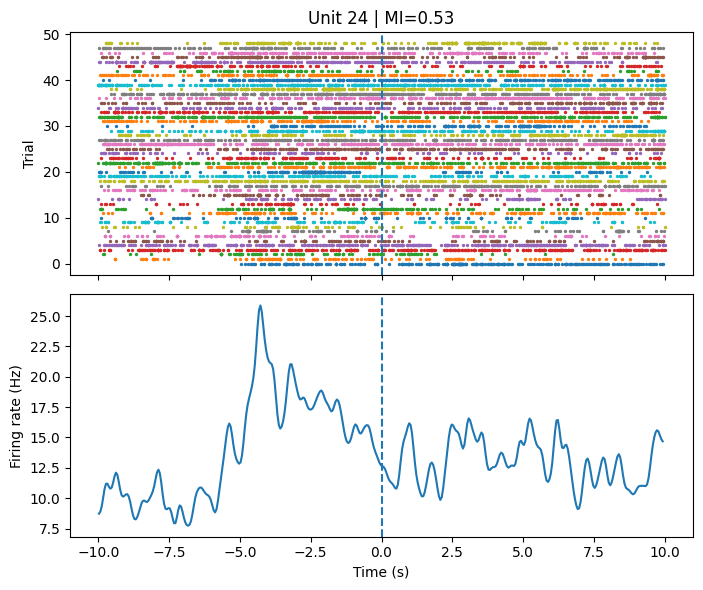

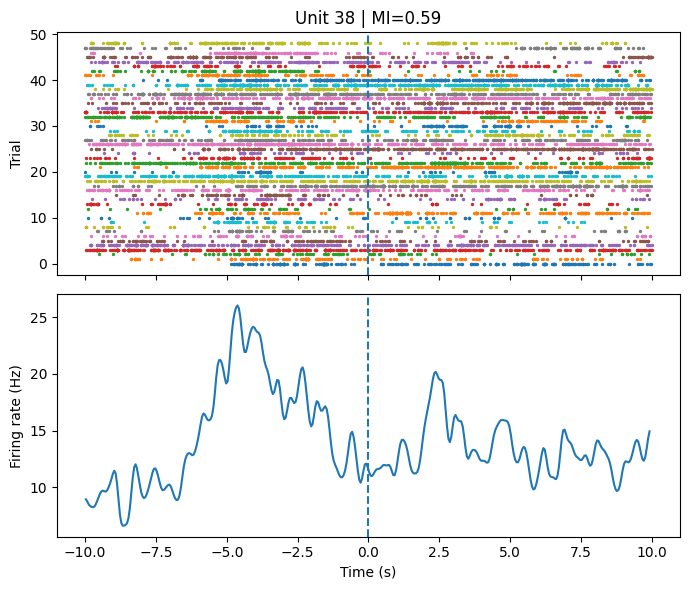

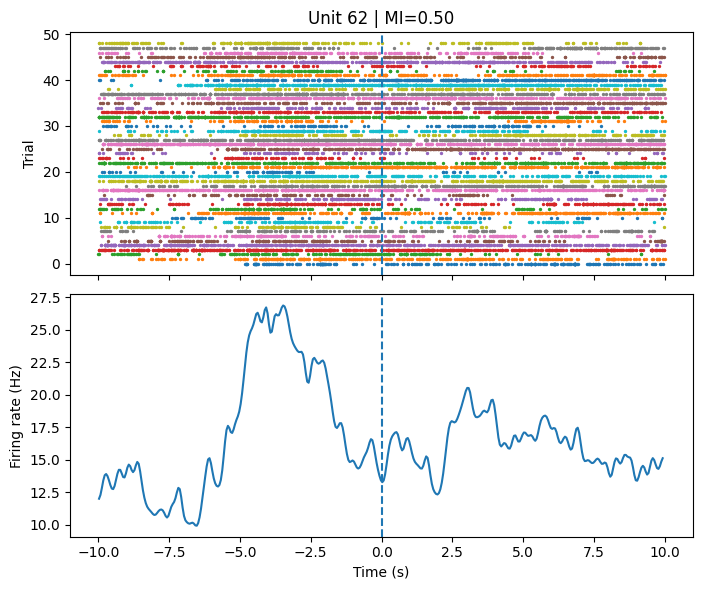

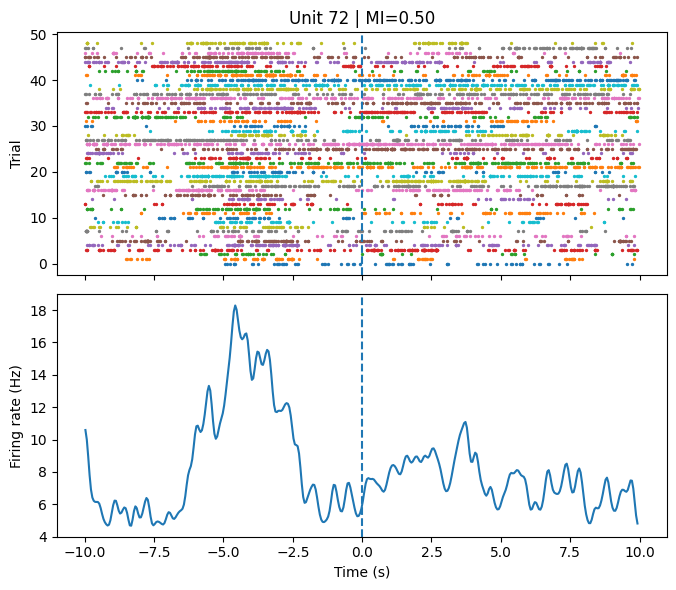

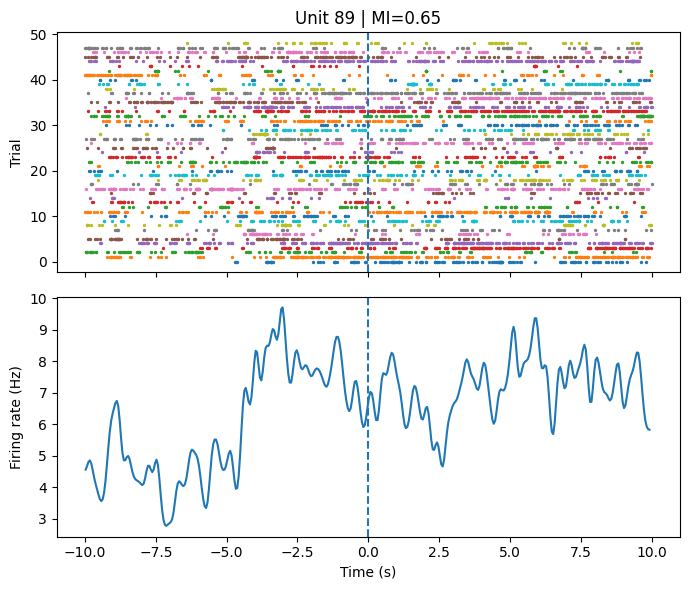

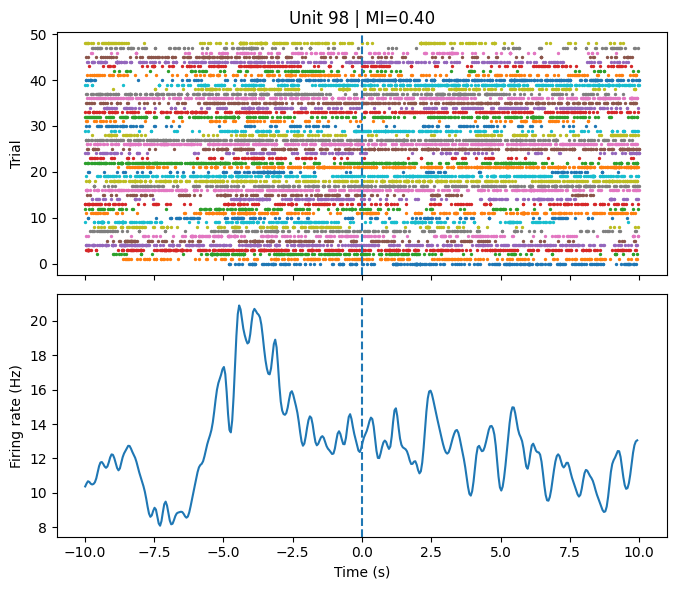

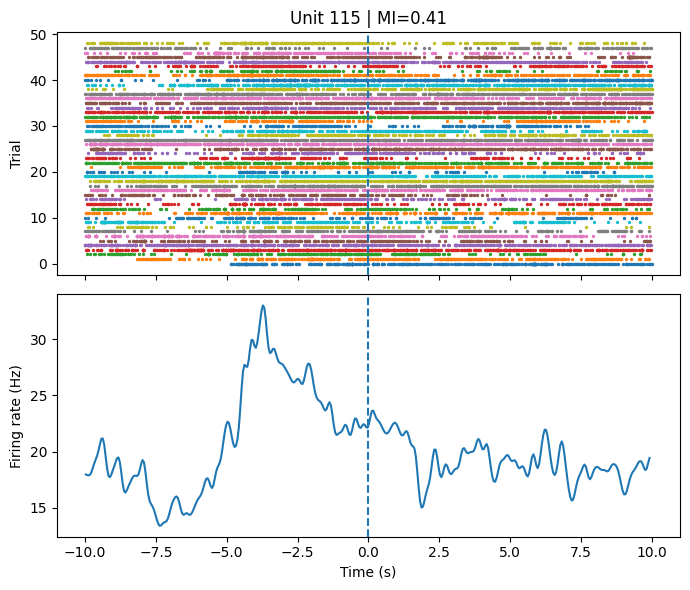

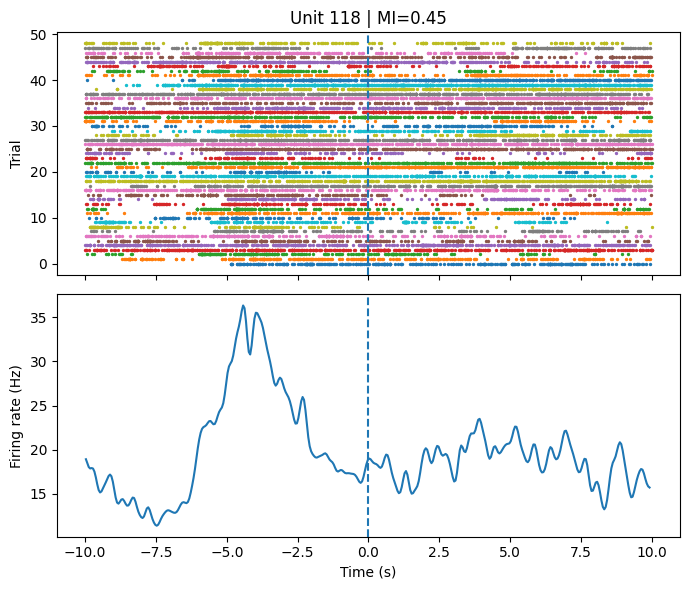

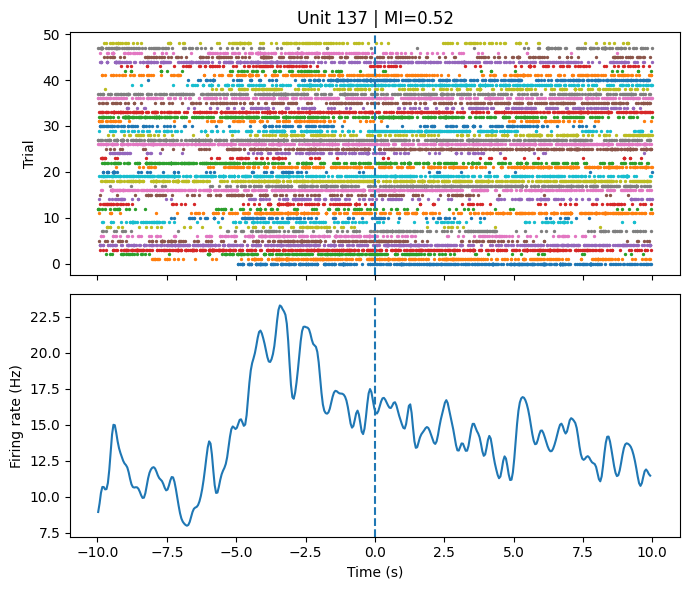

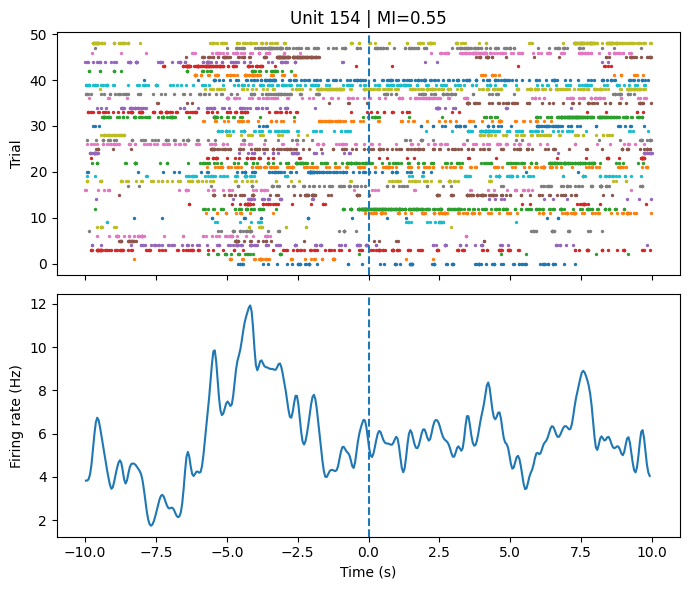

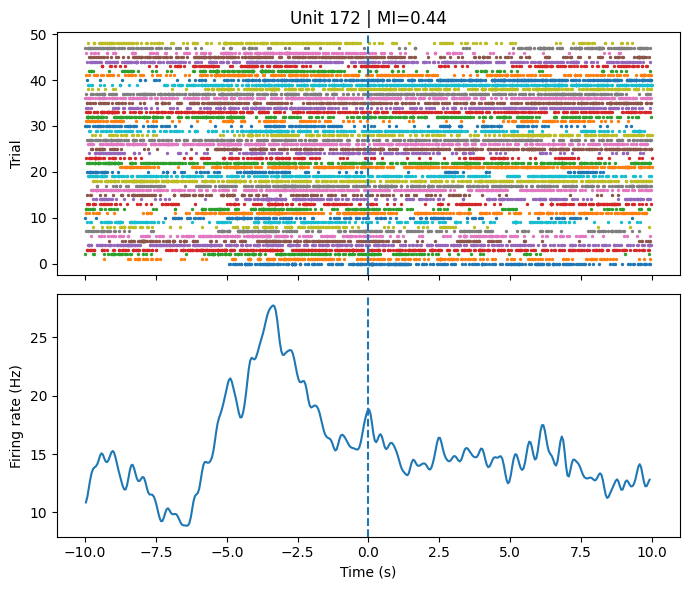

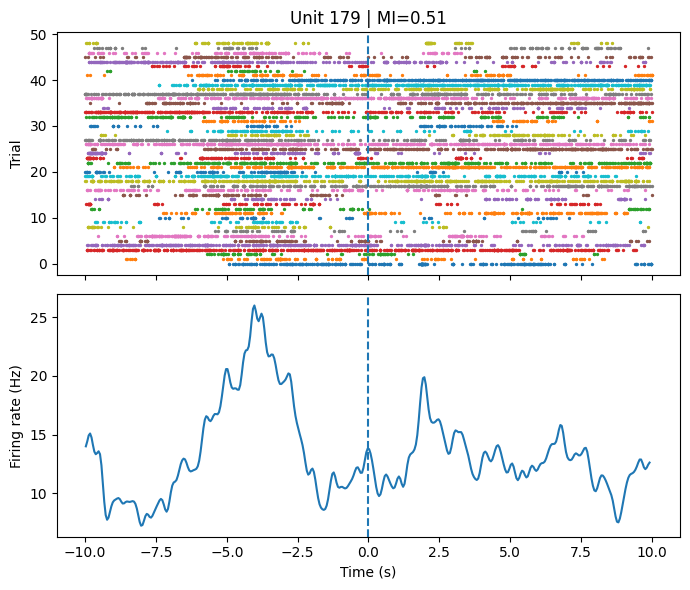

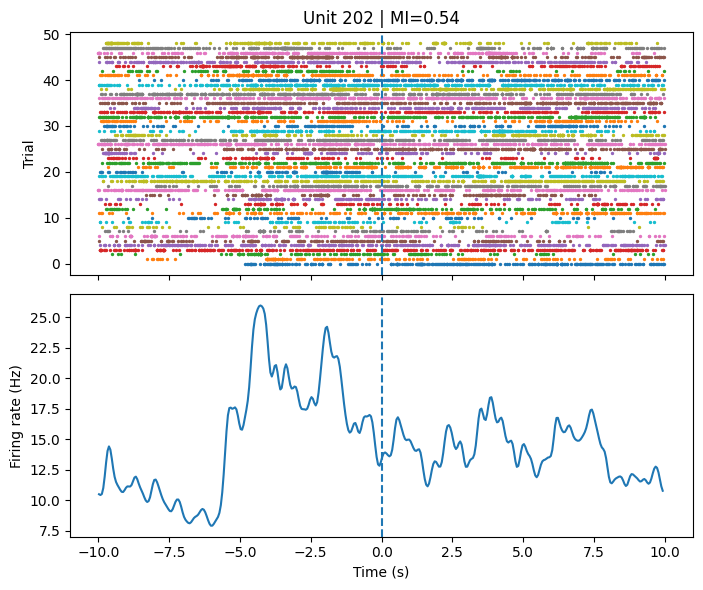

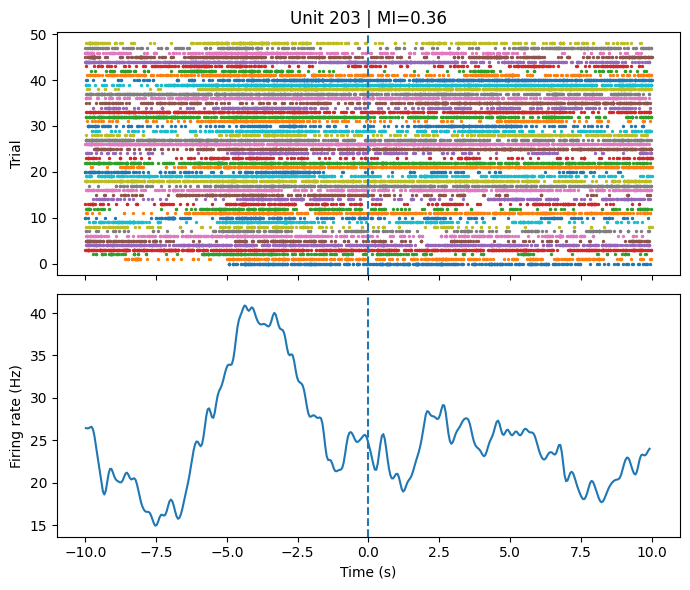

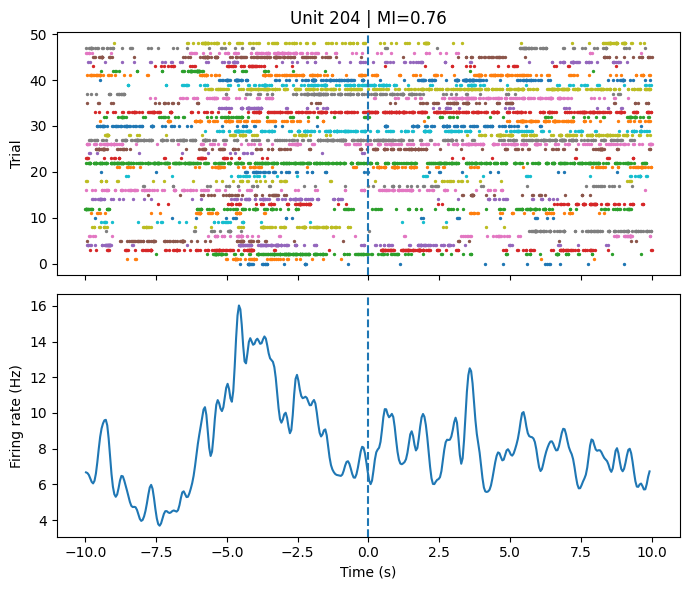

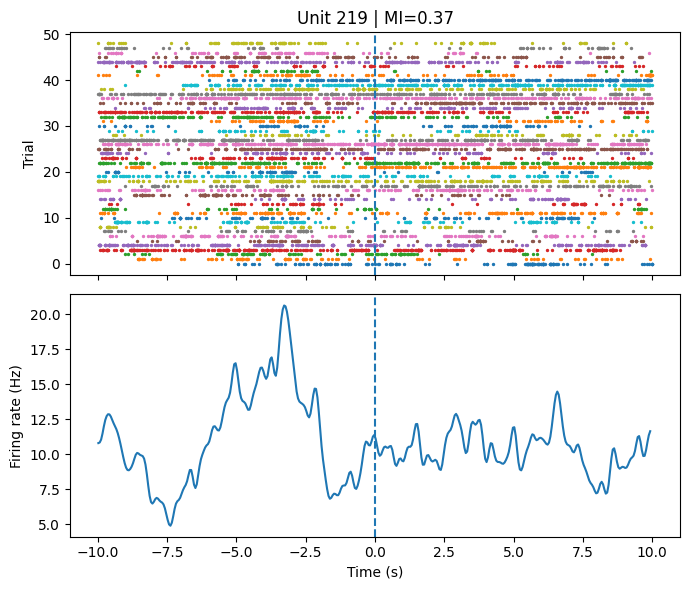

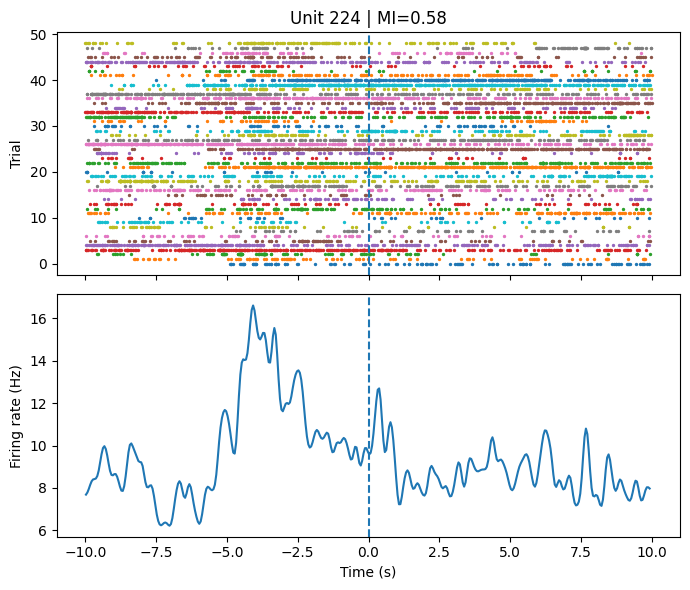

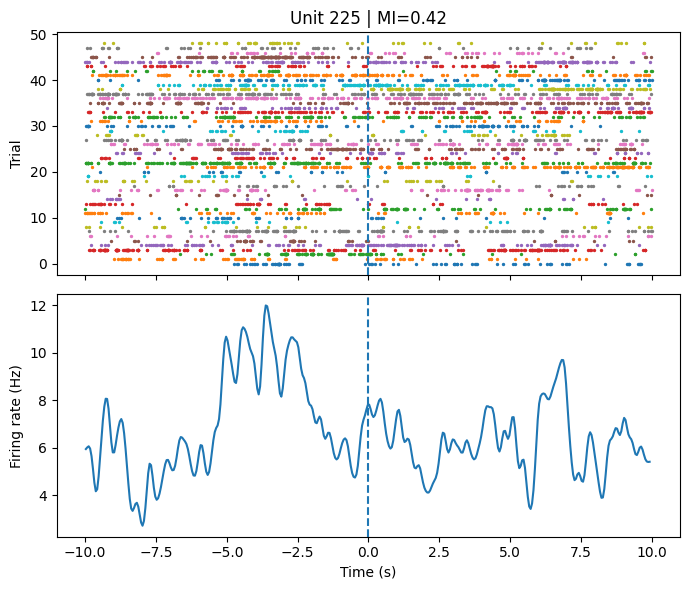

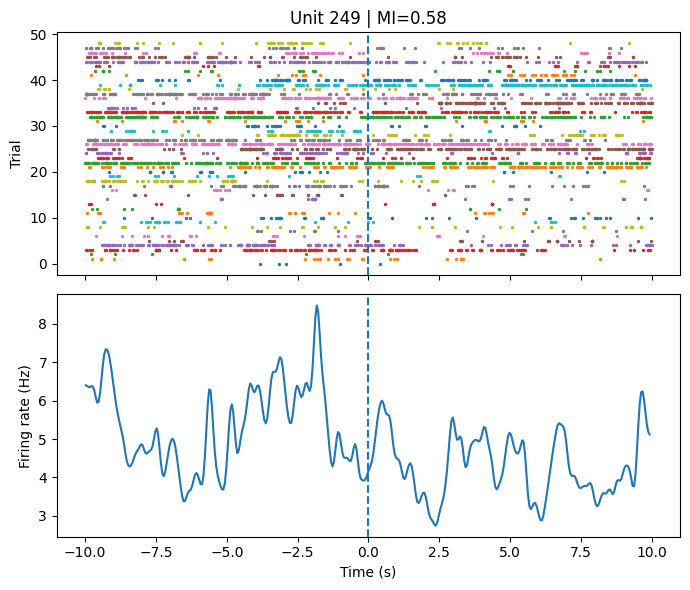

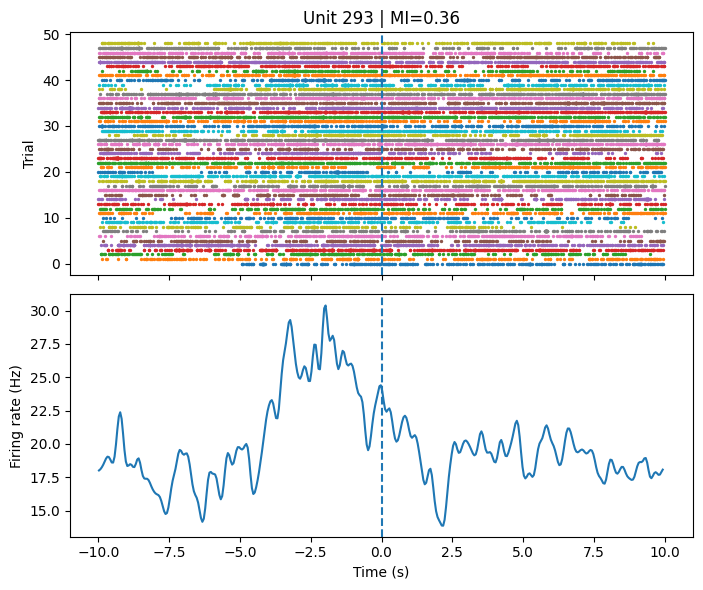

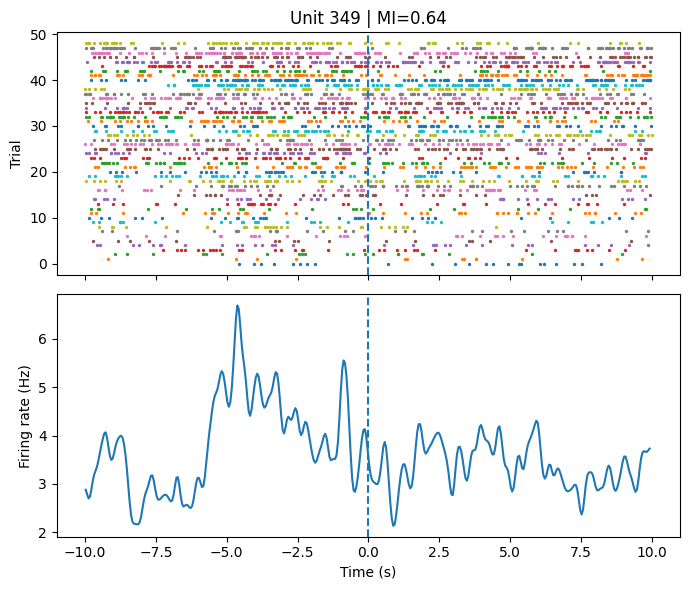

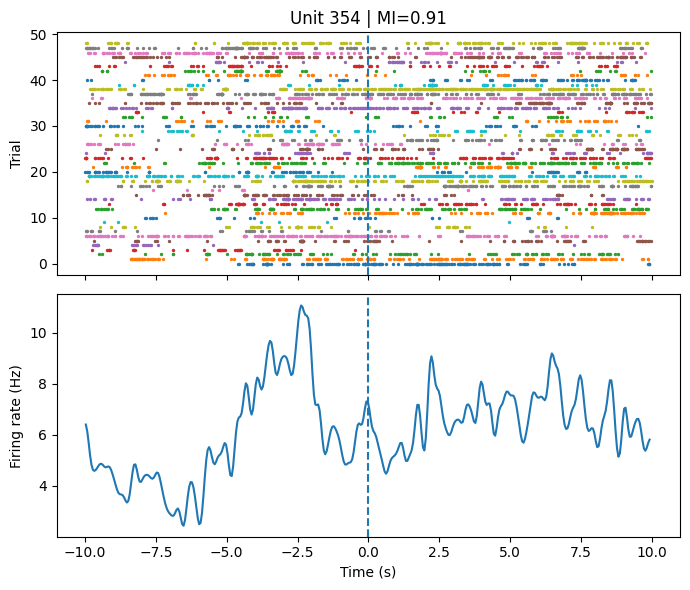

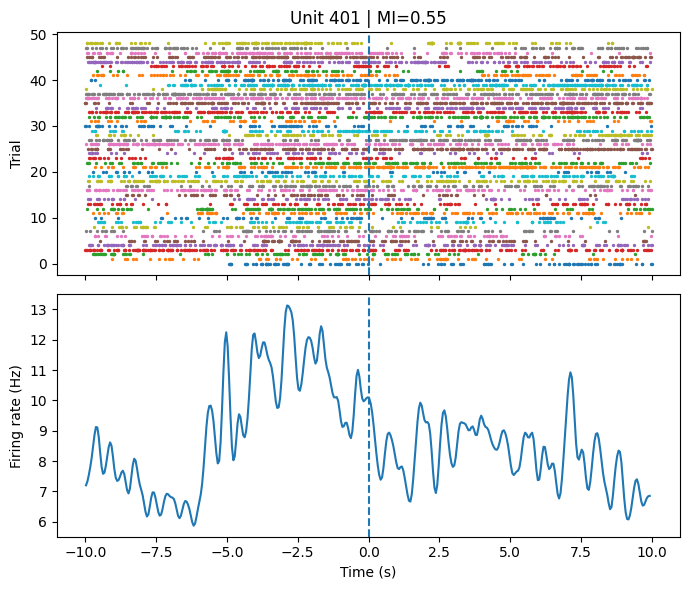

In [9]:
# =========================
# CELL 3: PLOT SELECTED UNITS
# =========================

from scipy.ndimage import gaussian_filter1d

MAX_PLOTS = 30
units_to_plot = selected_units[:MAX_PLOTS]

print(f"\n📊 Plotting {len(units_to_plot)} units...\n")

for unit in units_to_plot:

    spike_train = sorting_good.get_unit_spike_train(unit)
    spike_times = spike_train / sf

    aligned = []
    for t in ttl_times:
        rel = spike_times - t
        mask = (rel >= -pre_time) & (rel <= post_time)
        aligned.append(rel[mask])

    fig, (ax_raster, ax_peth) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

    # ---- RASTER ----
    for i, trial in enumerate(aligned):
        ax_raster.scatter(trial, np.ones_like(trial)*i, s=2)

    ax_raster.axvline(0, linestyle='--')
    ax_raster.set_ylabel("Trial")
    ax_raster.set_title(f"Unit {unit} | MI={modulation_info[unit]:.2f}")

    # ---- PETH ----
    bins = np.arange(-pre_time, post_time, bin_size)
    counts = np.zeros(len(bins)-1)

    for trial in aligned:
        h, _ = np.histogram(trial, bins=bins)
        counts += h

    rate = counts / (len(aligned) * bin_size)
    rate_smooth = gaussian_filter1d(rate, sigma=2)

    centers = (bins[:-1] + bins[1:]) / 2

    ax_peth.plot(centers, rate_smooth)
    ax_peth.axvline(0, linestyle='--')

    ax_peth.set_xlabel("Time (s)")
    ax_peth.set_ylabel("Firing rate (Hz)")

    plt.tight_layout()
    plt.show()

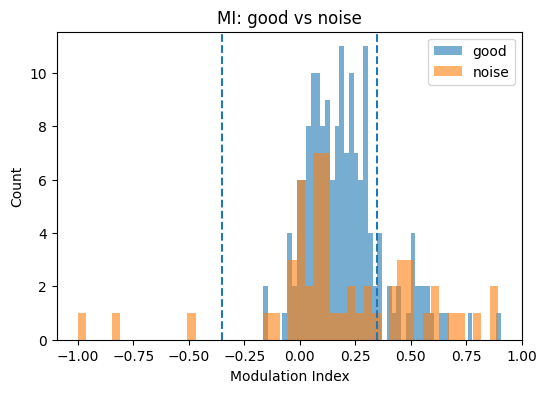


⚠️ Noise false positive rate: 0.345


In [10]:
# =========================
# CELL 5: MI COMPARISON
# =========================

plt.figure(figsize=(6,4))

plt.hist(list(modulation_info.values()), bins=50, alpha=0.6, label="good")
plt.hist(list(noise_MI.values()), bins=50, alpha=0.6, label="noise")

plt.axvline(MI_THRESHOLD, linestyle='--')
plt.axvline(-MI_THRESHOLD, linestyle='--')

plt.xlabel("Modulation Index")
plt.ylabel("Count")
plt.title("MI: good vs noise")
plt.legend()

plt.show()

# ---- false positive rate ----
fp_rate = len(noise_selected_units) / len(noise_units) if len(noise_units) > 0 else 0

print(f"\n⚠️ Noise false positive rate: {fp_rate:.3f}")